In [1]:
import albumentations as A
import segmentation_models_pytorch as smp
import glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import os 
from tqdm import tqdm
import random
import math
from pathlib import Path
import seaborn as sns
import torch
import torch.optim as optim
import torch.nn as nn
from utils.Loader.myLoader import SegDataset
from torch.utils.data import DataLoader
import cv2
matplotlib.rcParams['pdf.fonttype'] = 42

/home/bio-21/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/run/projects/bio-21/Anaconda3/envs/2D-seg/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [97]:
print(matplotlib.__version__)

3.10.7


In [2]:
os.makedirs("output",exist_ok = True)

os.makedirs("output/1-data_stats", exist_ok=True)
os.makedirs("output/2-demo_images", exist_ok = True)
os.makedirs("output/3-Model_performance", exist_ok=True)
os.makedirs("output/4-pred_ROIs",exist_ok=True)

# Get the path to Training Data and labels

In [3]:
data_dir = r"Dataset"
train_images = sorted(glob.glob(os.path.join(data_dir, "CXR", "*.jpg"), recursive=True))
train_labels = sorted(glob.glob(os.path.join(data_dir, "Mask", "*.jpg"), recursive=True))

len(train_labels) # check number of samples

200

In [4]:
train_images

['Dataset/CXR/001_disease.jpg',
 'Dataset/CXR/001_hc.jpg',
 'Dataset/CXR/002_disease.jpg',
 'Dataset/CXR/002_hc.jpg',
 'Dataset/CXR/003_disease.jpg',
 'Dataset/CXR/003_hc.jpg',
 'Dataset/CXR/004_disease.jpg',
 'Dataset/CXR/004_hc.jpg',
 'Dataset/CXR/005_disease.jpg',
 'Dataset/CXR/005_hc.jpg',
 'Dataset/CXR/006_disease.jpg',
 'Dataset/CXR/006_hc.jpg',
 'Dataset/CXR/007_disease.jpg',
 'Dataset/CXR/007_hc.jpg',
 'Dataset/CXR/008_disease.jpg',
 'Dataset/CXR/008_hc.jpg',
 'Dataset/CXR/009_disease.jpg',
 'Dataset/CXR/009_hc.jpg',
 'Dataset/CXR/010_disease.jpg',
 'Dataset/CXR/010_hc.jpg',
 'Dataset/CXR/011_disease.jpg',
 'Dataset/CXR/011_hc.jpg',
 'Dataset/CXR/012_disease.jpg',
 'Dataset/CXR/012_hc.jpg',
 'Dataset/CXR/013_disease.jpg',
 'Dataset/CXR/013_hc.jpg',
 'Dataset/CXR/014_disease.jpg',
 'Dataset/CXR/014_hc.jpg',
 'Dataset/CXR/015_disease.jpg',
 'Dataset/CXR/015_hc.jpg',
 'Dataset/CXR/016_disease.jpg',
 'Dataset/CXR/016_hc.jpg',
 'Dataset/CXR/017_disease.jpg',
 'Dataset/CXR/017_hc.jpg

In [5]:
train_labels

['Dataset/Mask/001_disease_mask.jpg',
 'Dataset/Mask/001_hc_mask.jpg',
 'Dataset/Mask/002_disease_mask.jpg',
 'Dataset/Mask/002_hc_mask.jpg',
 'Dataset/Mask/003_disease_mask.jpg',
 'Dataset/Mask/003_hc_mask.jpg',
 'Dataset/Mask/004_disease_mask.jpg',
 'Dataset/Mask/004_hc_mask.jpg',
 'Dataset/Mask/005_disease_mask.jpg',
 'Dataset/Mask/005_hc_mask.jpg',
 'Dataset/Mask/006_disease_mask.jpg',
 'Dataset/Mask/006_hc_mask.jpg',
 'Dataset/Mask/007_disease_mask.jpg',
 'Dataset/Mask/007_hc_mask.jpg',
 'Dataset/Mask/008_disease_mask.jpg',
 'Dataset/Mask/008_hc_mask.jpg',
 'Dataset/Mask/009_disease_mask.jpg',
 'Dataset/Mask/009_hc_mask.jpg',
 'Dataset/Mask/010_disease_mask.jpg',
 'Dataset/Mask/010_hc_mask.jpg',
 'Dataset/Mask/011_disease_mask.jpg',
 'Dataset/Mask/011_hc_mask.jpg',
 'Dataset/Mask/012_disease_mask.jpg',
 'Dataset/Mask/012_hc_mask.jpg',
 'Dataset/Mask/013_disease_mask.jpg',
 'Dataset/Mask/013_hc_mask.jpg',
 'Dataset/Mask/014_disease_mask.jpg',
 'Dataset/Mask/014_hc_mask.jpg',
 'Data

In [6]:
# convert to dict for easy manipulation
data_dicts = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
len(data_dicts)

200

In [7]:
data_dicts # check it's correctly paired !!! important !!!

[{'image': 'Dataset/CXR/001_disease.jpg',
  'label': 'Dataset/Mask/001_disease_mask.jpg'},
 {'image': 'Dataset/CXR/001_hc.jpg', 'label': 'Dataset/Mask/001_hc_mask.jpg'},
 {'image': 'Dataset/CXR/002_disease.jpg',
  'label': 'Dataset/Mask/002_disease_mask.jpg'},
 {'image': 'Dataset/CXR/002_hc.jpg', 'label': 'Dataset/Mask/002_hc_mask.jpg'},
 {'image': 'Dataset/CXR/003_disease.jpg',
  'label': 'Dataset/Mask/003_disease_mask.jpg'},
 {'image': 'Dataset/CXR/003_hc.jpg', 'label': 'Dataset/Mask/003_hc_mask.jpg'},
 {'image': 'Dataset/CXR/004_disease.jpg',
  'label': 'Dataset/Mask/004_disease_mask.jpg'},
 {'image': 'Dataset/CXR/004_hc.jpg', 'label': 'Dataset/Mask/004_hc_mask.jpg'},
 {'image': 'Dataset/CXR/005_disease.jpg',
  'label': 'Dataset/Mask/005_disease_mask.jpg'},
 {'image': 'Dataset/CXR/005_hc.jpg', 'label': 'Dataset/Mask/005_hc_mask.jpg'},
 {'image': 'Dataset/CXR/006_disease.jpg',
  'label': 'Dataset/Mask/006_disease_mask.jpg'},
 {'image': 'Dataset/CXR/006_hc.jpg', 'label': 'Dataset/Mask

# Statistical Analysis on image pixels

In [8]:
image_height = []
image_width = []
roi_pixel_counts = []
roi_ratios = []
image_names = []
empty_masks_count = 0

pixel_sum = 0.0
pixel_sq_sum = 0.0
pixel_count = 0

for sample in tqdm(data_dicts, desc="Analyzing dataset"):
    # load image (grayscale or RGB as needed)
    img = cv2.imread(sample["image"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(sample["label"], cv2.IMREAD_GRAYSCALE)

    image_names.append(Path(sample['image']).stem)

    h, w = img.shape
    image_height.append(h)
    image_width.append(w)

    # ---- image stats ----
    # img = img.astype(np.float32) / 255.0
    # pixel_sum += img.sum()
    # pixel_sq_sum += (img ** 2).sum()
    # pixel_count += img.size

    # ---- mask stats ----
    roi = (mask > 0).astype(np.uint8)
    roi_pixels = roi.sum()

    roi_pixel_counts.append(roi_pixels)
    roi_ratios.append(roi_pixels / (h * w))

    if roi_pixels == 0:
        empty_masks_count += 1

print(f"Empty Masks in this Dataset: {empty_masks_count}")

img_stats_df = pd.DataFrame({
    "Image_Name":image_names,
    "Image_height":image_height,
    "Image_width":image_width,
    "ROI_ratio": roi_ratios,
})

img_stats_df.to_csv("output/1-data_stats/image_stats.csv",index=False)

Analyzing dataset: 100%|██████████| 173/173 [00:20<00:00,  8.56it/s]

Empty Masks in this Dataset: 0


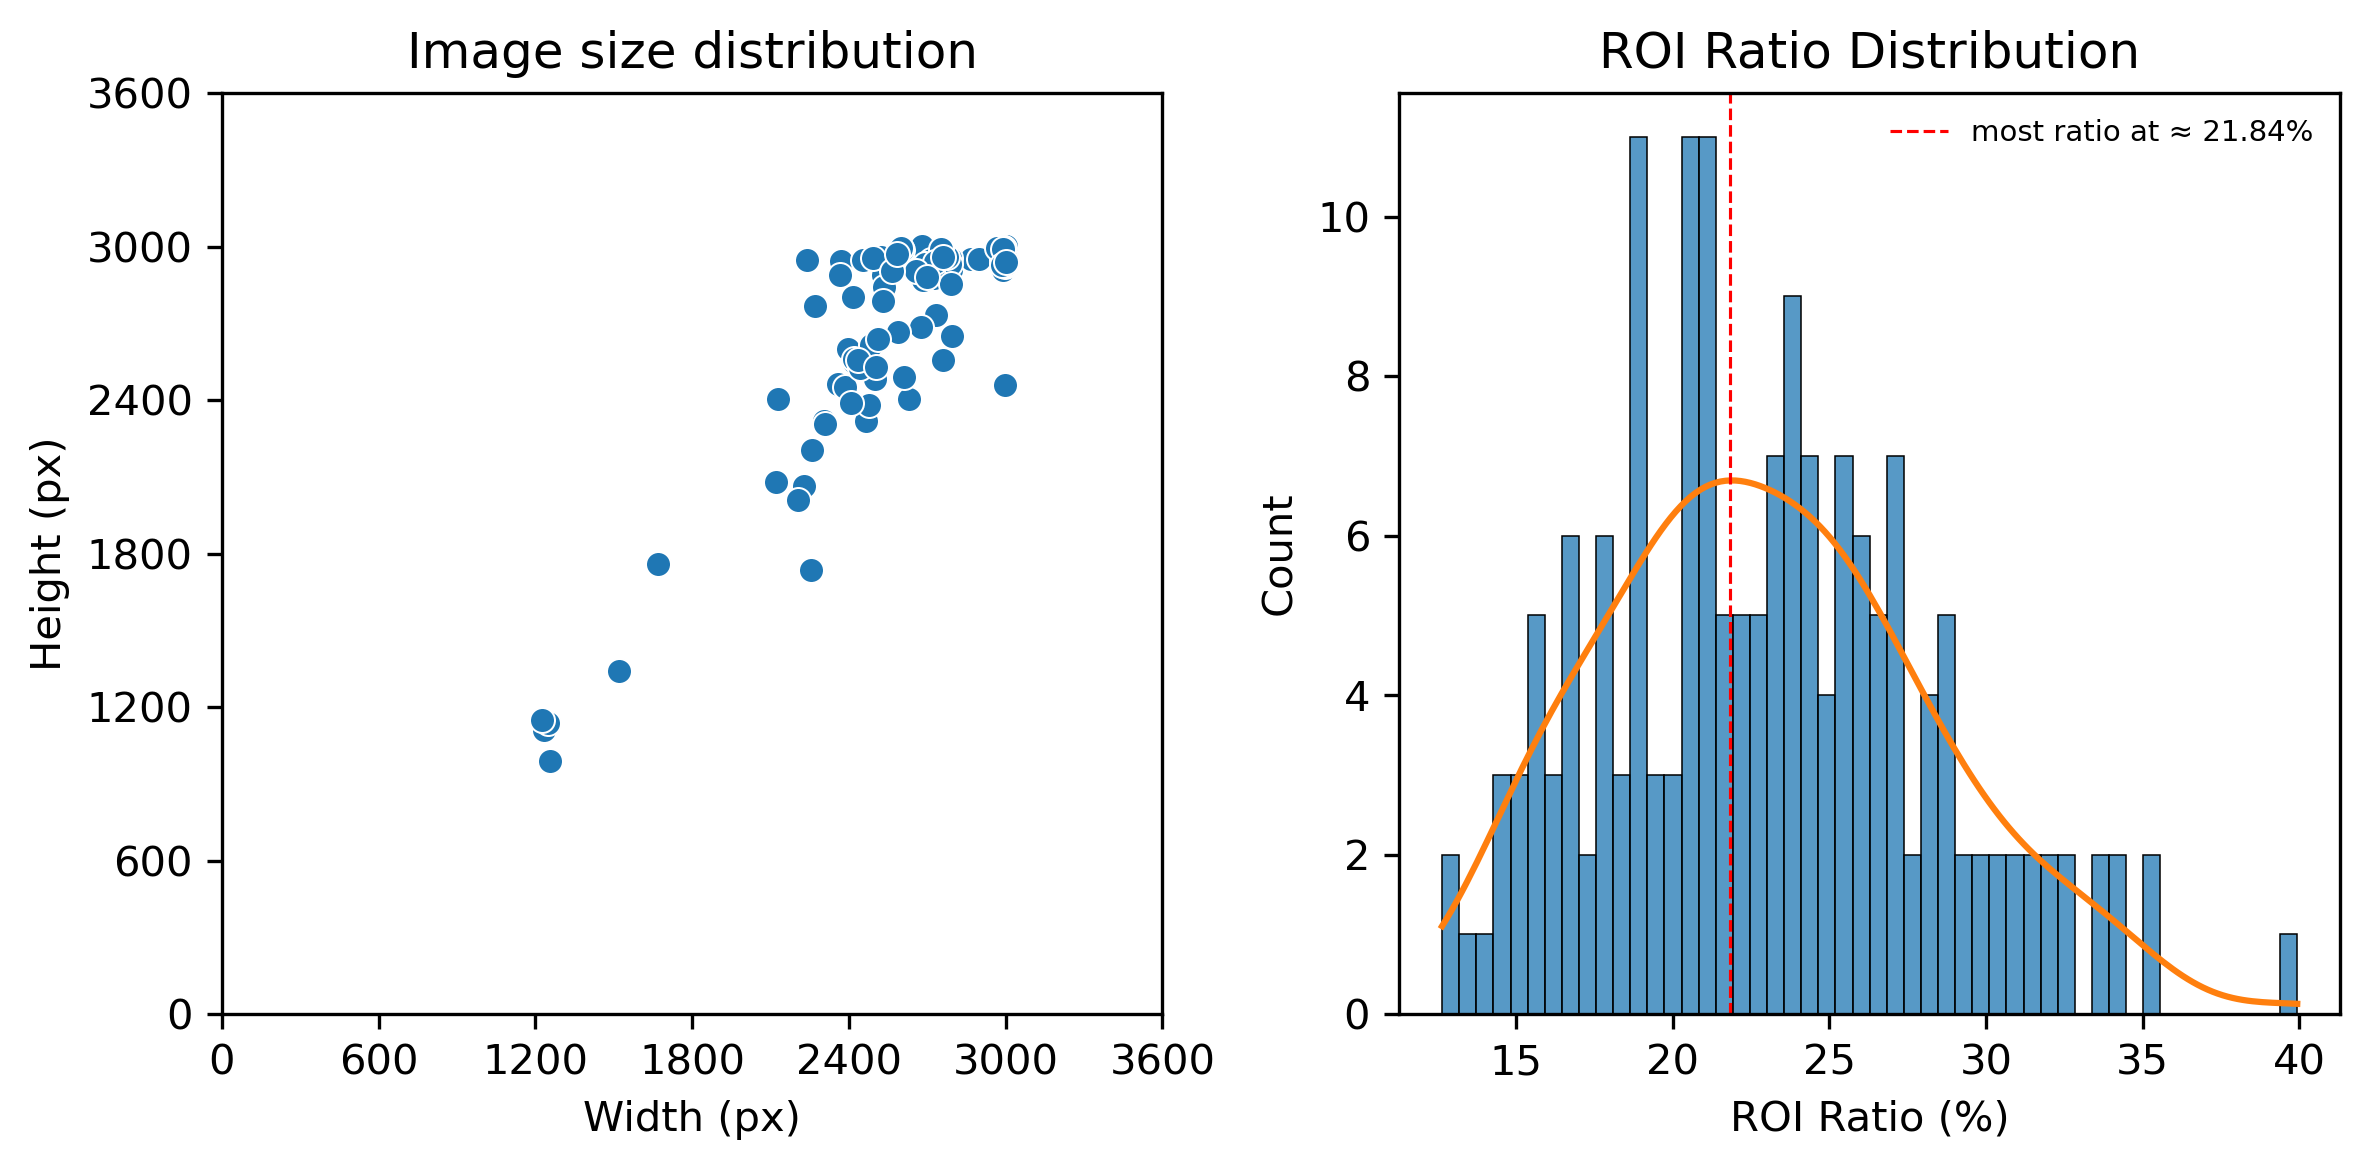

In [9]:
from scipy.stats import gaussian_kde
max_tick = max(img_stats_df["Image_height"].max(), img_stats_df["Image_width"].max())
max_tick_step = max_tick // 5
plt.figure(figsize=(8,4), dpi=300)

plt.subplot(121)
sns.scatterplot(data=img_stats_df, x="Image_width", y="Image_height")
plt.xticks(range(0,max_tick+max_tick_step,max_tick_step))
plt.yticks(range(0,max_tick+max_tick_step,max_tick_step))
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image size distribution")

plt.subplot(122)

data = img_stats_df["ROI_ratio"] * 100
bins = 50
bin_width = (data.max() - data.min()) / bins

ax = sns.histplot(data, bins=bins, color="tab:blue", edgecolor="black", stat="count")

# KDE line
# KDE (smoothed count)
kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), len(data))
y = kde(x) * len(data) * bin_width
ax.plot(x, y, color="tab:orange", linewidth=1.5)
mode = x[np.argmax(y)]
ax.axvline(mode, color="red", linestyle="--", label=f"most ratio at ≈ {mode:.2f}%", linewidth= 0.75)
ax.legend(fontsize=7,loc='upper right', frameon=False )
# sns.kdeplot(img_stats_df["ROI_ratio"] * 100, color="tab:orange", linewidth=0.75,ax=ax,common_norm=False)

plt.xlabel("ROI Ratio (%)")
plt.ylabel("Count")
plt.title("ROI Ratio Distribution")

plt.tight_layout()
plt.savefig("output/1-data_stats/image_stats.pdf", format = "pdf")
plt.show()

# Split the dataset, 70% train, 15% validation, 15% test

In [8]:
random.seed(42)
random.shuffle(data_dicts)
# calculate splits
train_portion = math.ceil(len(data_dicts) * 0.7)
test_portion = math.floor(len(data_dicts) * 0.15)
valid_portion = len(data_dicts) - test_portion - train_portion
print(train_portion)
print(test_portion)
print(valid_portion)
print((train_portion + test_portion + valid_portion) == len(data_dicts))
train_files, test_files, val_files = data_dicts[0:train_portion], data_dicts[train_portion:(train_portion+test_portion)], data_dicts[(train_portion+test_portion):(train_portion + test_portion + valid_portion)]

140
30
30
True


In [27]:
import pickle

with open("output/train_files.pkl", "wb") as f:
    pickle.dump(train_files,f)

with open("output/val_files.pkl", "wb") as f:
    pickle.dump(val_files,f)

with open("output/test_files.pkl", "wb") as f:
    pickle.dump(test_files,f)

## visualize one sample, make sure it is correctly reading the file 

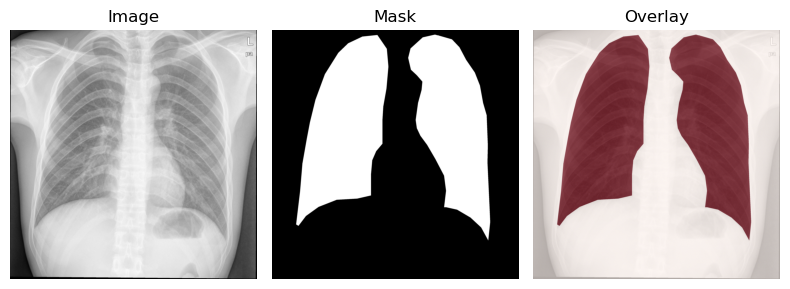

In [12]:
import cv2

sample = random.choice(data_dicts) # randomly choose one
image = cv2.imread(sample["image"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(sample["label"], cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(8, 4))

axes[0].imshow(image)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

# Overlay
axes[2].imshow(image)
axes[2].imshow(mask, cmap="Reds", alpha=0.7)  # alpha controls transparency
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

fig.savefig(f"output/2-demo_images/demonstration-of-sample-{Path(sample['image']).stem}.pdf",format = "pdf")


# prepare the augmentation

In [9]:
TARGET_SIZE = (224, 224) # Example input height, width
# https://explore.albumentations.ai/ see the augmentations
train_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    # Take a random crop
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    # Apply one of 8 random symmetries (flips/rotations)
    A.SquareSymmetry(p=0.3), # Replaces Horizontal/Vertical Flips
    # Optional: Further rotation if SquareSymmetry isn't sufficient or desired
    A.Rotate(limit=30, p=0.3),
    # Optional: Image-only transforms (applied only to image)
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(std_range=(0.1, 0.2), p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    # --- Framework-specific steps ---
    # Normalize image (mask is not normalized)
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    # Convert image and mask to PyTorch tensors
    A.ToTensorV2()
],seed=42)

val_transform = A.Compose([
    # Resize shortest side of image and mask to TARGET_SIZE * 2, maintaining aspect ratio
    A.SmallestMaxSize(max_size=TARGET_SIZE[0], p=1.0),
    A.RandomCrop(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.CropNonEmptyMaskIfExists(height=TARGET_SIZE[0], width=TARGET_SIZE[1], p=1.0),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    # Convert image and mask to PyTorch tensors
    A.ToTensorV2()
],seed=42)

In [14]:
train_dataset = SegDataset(train_files, transform=train_transform)
val_dataset   = SegDataset(val_files, transform=val_transform)
test_dataset   = SegDataset(test_files, transform=val_transform)

14


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9215687..0.7019608].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9215687..0.7019608].


torch.Size([3, 224, 224])


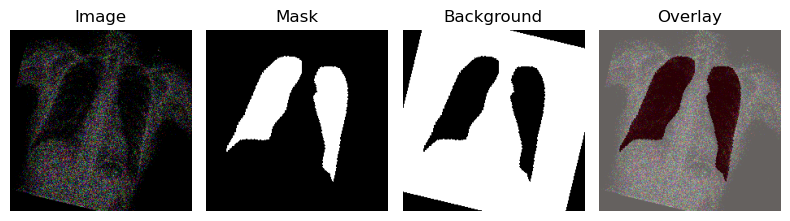

In [17]:
# from matplotlib.colors import ListedColormap

idx = random.randrange(len(train_dataset))
print(idx)
image1, mask1, sample = train_dataset[idx]
print(image1.shape) # should be in form (C, H, W)
# image: (C, H, W), normalized
# print(augmented["image"].shape)
# print(augmented["mask"].shape)
img_np = image1.permute(1, 2, 0).cpu().numpy() # make sure (H, W, C)

# # undo normalization for display
# img_np = (img_np * 0.5 + 0.5).clip(0, 1)

mask_np = mask1.squeeze(0).cpu().numpy()
# background_np = background.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(8, 4))

axes[0].imshow(img_np)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_np[0],cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(mask_np[1],cmap="gray")
axes[2].set_title("Background")
axes[2].axis("off")

axes[3].imshow(img_np)
axes[3].imshow(mask_np[0], cmap="Reds", alpha=0.4) # ListedColormap(["#FFFFFF"])
axes[3].set_title("Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()

fig.savefig(f"output/2-demo_images/transformed-of-sample-{Path(sample['image']).stem}.pdf",format = "pdf")

# Preparation

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device # check device

device(type='cuda')

## Building model

In [4]:
# building model
Unet_model = smp.Unet(
                encoder_name="efficientnet-b0",
                encoder_weights=None,
                decoder_interpolation = "bilinear",
                in_channels=3,
                classes=2,
                activation=None
            )
model=Unet_model.to(device) # move model to device

# Define the loss function and optimizer
# criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001) # adam optimizer

loss_fn = smp.losses.DiceLoss(mode='multilabel') # dice loss, main loss

# loss_fn = smp.losses.DiceLoss(mode='multilabel')
JaccardLoss_loss_fn = smp.losses.JaccardLoss(mode='multilabel')
TverskyLoss_loss_fn = smp.losses.TverskyLoss(mode='multilabel')
FocalLoss_loss_fn = smp.losses.FocalLoss(mode='multilabel')
LovaszLoss_loss_fn = smp.losses.LovaszLoss(mode='multilabel')

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

In [5]:
model

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

# Training

## Hyperparameters

In [ ]:
# pre-defined best metrics, for model selection and saving
best_f1         = 0.6
best_recall     = 0.7
best_acc        = 0.7
best_train_loss = 0.3
best_val_loss   = 0.3
best_IOU        = 0.5

# simple hyperparameters, normally this set up can have a result of around 0.7 IoU, depends on the number of masks
epochs          = 200 # train for 200 epochs
batch_size      = 16 # adjust batch to optimize the use of GPU, 224 * 224 @ batch size 16 takes up around 3GB of GPU Memory


In [ ]:
# lists to store metrics
train_losses = []
eval_losses = []
iou_scores = []
f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []
fbeta_scores = []
num_epoch = []

JaccardLosses = []
TverskyLosses = []
FocalLosses = []
LovaszLosses = []

eval_JaccardLosses = []
eval_TverskyLosses= []
eval_FocalLosses  = []
eval_LovaszLosses = []


In [20]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
pbar = tqdm(range(epochs))
len_loader = len(train_loader)
len_eval_loader = len(val_loader)

for epoch in pbar:
    epoch_loss = 0
    epoch_JaccardLoss = 0
    epoch_TverskyLoss = 0
    epoch_FocalLoss = 0
    epoch_LovaszLoss = 0

    num_epoch.append(epoch)
    
    model.train() # enable training mode
    for image, masks, types in train_loader:
        pbar.set_description("Training ...")
        
        # print(f"{image.shape} {masks.shape}")
        # img_np = image.squeeze(0).permute(1, 2, 0).numpy() # make sure (H, W, C)
        # print(f"{img_np.shape}")
        # mask_np = masks.squeeze(0).permute(1, 2, 0).numpy()
        # fig, axes = plt.subplots(1, 3, figsize=(8, 4))

        # axes[0].imshow(img_np)
        # axes[0].set_title("Image")
        # axes[0].axis("off")

        # axes[1].imshow(mask_np, cmap="gray")
        # axes[1].set_title("Mask")
        # axes[1].axis("off")

        # axes[2].imshow(img_np)
        # axes[2].imshow(mask_np, cmap="Reds", alpha=0.4) # ListedColormap(["#FFFFFF"])
        # axes[2].set_title("Overlay")
        # axes[2].axis("off")

        # plt.tight_layout()
        # plt.show()

        image = image.to(device)
        masks = masks.to(device)
        # print(f"{image.shape} {masks.shape}")
        optimizer.zero_grad()

        outputs = model(image)
        loss = loss_fn(outputs, masks) # compute dice loss

        loss.backward() # back propagation
        optimizer.step() # optimize weights

        epoch_loss += loss.item()

        # compute other loss
        JaccardLoss = JaccardLoss_loss_fn(outputs, masks)
        TverskyLoss = TverskyLoss_loss_fn(outputs, masks)
        FocalLoss = FocalLoss_loss_fn(outputs, masks)
        LovaszLoss = LovaszLoss_loss_fn(outputs, masks)

        epoch_JaccardLoss += JaccardLoss.item()
        epoch_TverskyLoss += TverskyLoss.item()
        epoch_FocalLoss += FocalLoss.item()
        epoch_LovaszLoss += LovaszLoss.item()
        # print(f"{image.shape} {masks.shape}")
    #     break
    # break
    
    avg_train_loss = epoch_loss / len_loader
    avg_JaccardLoss = epoch_JaccardLoss / len_loader
    avg_TverskyLoss = epoch_TverskyLoss / len_loader
    avg_FocalLoss = epoch_FocalLoss / len_loader
    avg_LovaszLoss = epoch_LovaszLoss / len_loader

    train_losses.append(avg_train_loss)
    JaccardLosses.append(avg_JaccardLoss)
    TverskyLosses.append(avg_TverskyLoss)
    FocalLosses.append(avg_FocalLoss)
    LovaszLosses.append(avg_LovaszLoss)

    # evaluation loop
    model.eval() # enable model evaluation mode
    # stop gradient calculation
    val_loss = 0
    val_JaccardLoss= 0
    val_TverskyLoss= 0
    val_FocalLoss = 0
    val_LovaszLoss = 0

    with torch.no_grad():
        all_tp, all_fp, all_fn, all_tn = [], [], [], []
        for image, masks,types in val_loader:
            pbar.set_description("Validating ...")
            # print(masks)
            image = image.to(device)
            masks = masks.to(device)

            outputs = model(image)
            loss = loss_fn(outputs, masks)

            val_loss += loss.item()
            outputs = torch.sigmoid(outputs)
            # print(f"{outputs[:, 0:1].shape}")
            tp, fp, fn, tn = smp.metrics.get_stats(
                outputs[:,0], masks.long()[:,0], mode='binary', threshold=0.5#, num_classes=2
            )

            JaccardLoss = JaccardLoss_loss_fn(outputs, masks)
            TverskyLoss = TverskyLoss_loss_fn(outputs, masks)
            FocalLoss = FocalLoss_loss_fn(outputs, masks)
            LovaszLoss = LovaszLoss_loss_fn(outputs, masks)

            val_JaccardLoss += JaccardLoss.item()
            val_TverskyLoss += TverskyLoss.item()
            val_FocalLoss += FocalLoss.item()
            val_LovaszLoss += LovaszLoss.item()
            
            all_tp.append(tp)
            all_fp.append(fp)
            all_fn.append(fn)
            all_tn.append(tn)

        avg_val_loss = val_loss / len_eval_loader
        avg_eval_JaccardLoss = val_JaccardLoss / len_eval_loader
        avg_eval_TverskyLoss = val_TverskyLoss / len_eval_loader
        avg_eval_FocalLoss  = val_FocalLoss / len_eval_loader
        avg_eval_LovaszLoss = val_LovaszLoss / len_eval_loader
        
        eval_losses.append(avg_val_loss)
        eval_JaccardLosses.append(avg_eval_JaccardLoss)
        eval_TverskyLosses.append(avg_eval_TverskyLoss)
        eval_FocalLosses.append(avg_eval_FocalLoss)
        eval_LovaszLosses.append(avg_eval_LovaszLoss) 


        scheduler.step(avg_val_loss)
        
        # Concatenate statistics
        tp = torch.cat(all_tp, dim=0)
        fp = torch.cat(all_fp, dim=0)
        fn = torch.cat(all_fn, dim=0)
        tn = torch.cat(all_tn, dim=0)

        # Compute metrics
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
        f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
        precision = smp.metrics.precision(tp, fp, fn, tn, reduction="macro")
        recall = smp.metrics.recall(tp, fp, fn, tn, reduction="micro-imagewise")
        accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")
        fbeta = smp.metrics.fbeta_score(tp, fp, fn, tn, reduction="macro")

        current_lr = optimizer.param_groups[0]['lr']

        pbar.set_postfix({"Validation IOU": iou.item(), "Dice": avg_val_loss, "current learning rate": scheduler.get_last_lr()})

        iou_scores.append(float(iou.cpu().numpy()))
        f1_scores.append(float(f1.cpu().numpy()))
        precision_scores.append(float(precision.cpu().numpy()))
        recall_scores.append(float(recall.cpu().numpy()))
        accuracy_scores.append(float(accuracy.cpu().numpy()))
        fbeta_scores.append(float(fbeta.cpu().numpy()))

        

        if iou.item() > best_IOU or (avg_train_loss < best_train_loss and 
                                     avg_val_loss < best_val_loss and 
                                     f1 > best_f1 and 
                                     recall > best_recall and 
                                     accuracy > best_acc):
                best_f1     = f1
                best_recall = recall
                best_acc    = accuracy
                best_train_loss = avg_train_loss
                best_val_loss = avg_val_loss
                best_IOU = iou
                model.save_pretrained(f'./my_model/{epoch}', metrics={"epoch":epoch, 
                                                                      "IOU": iou.item(), 
                                                                      "accuracy": accuracy.item(), 
                                                                      "F1": f1.item(), 
                                                                      "Precision":precision.item(), 
                                                                      "Recall":recall.item(),
                                                                      "Dice":avg_val_loss})

metrics_df = pd.DataFrame({
    "Epoch": num_epoch,
    "IoU": iou_scores,
    "F1": f1_scores,
    "Fbeta": fbeta_scores,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "Accuracy" : accuracy_scores,
    "Training_loss" : train_losses,
    "Validation_loss": eval_losses,
    "Train_Jaccard_Loss": JaccardLosses,
    "Train_Tversky_Loss": TverskyLosses,
    "Train_Focal_Loss": FocalLosses,
    "Train_Lovasz_Loss": LovaszLosses,
    "Eval_Jaccard_Loss":eval_JaccardLosses ,
    "Eval_Tversky_Loss":eval_TverskyLosses,
    "Eval_Focal_Loss" : eval_FocalLosses  ,
    "Eval_Lovasz_Loss": eval_LovaszLosses 
})

metrics_df.to_csv("output/3-Model_performance/model_metrics.csv", index=False)

  0%|          | 0/200 [00:00<?, ?it/s]

Validating ...: 100%|██████████| 200/200 [1:12:12<00:00, 21.66s/it, Validation IOU=0.752, Dice=0.113, current learning rate=1e-8] 


In [22]:
metrics_df

,Epoch,IoU,F1,Fbeta,Precision,Recall,Accuracy,Training_loss,Validation_loss,Train_Jaccard_Loss,Train_Tversky_Loss,Train_Focal_Loss,Train_Lovasz_Loss,Eval_Jaccard_Loss,Eval_Tversky_Loss,Eval_Focal_Loss,Eval_Lovasz_Loss
0,0,0.285561,0.452389,0.397652,0.288745,0.972906,0.415440,0.463110,0.486560,0.620080,0.463110,0.303127,1.221647,0.622360,0.471069,0.226131,0.976618
1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.741163,0.351390,0.453156,0.502809,0.351390,0.189792,0.828793,0.612046,0.462803,0.219873,0.937825
2,2,0.017857,0.000000,0.017857,0.133929,0.000000,0.745921,0.296783,0.453277,0.439847,0.296783,0.166900,0.665038,0.606963,0.459927,0.207605,0.899147
3,3,0.035714,0.000000,0.035714,0.995536,0.000000,0.751344,0.255977,0.467604,0.392026,0.255977,0.168622,0.591562,0.606555,0.460401,0.197040,0.877751
4,4,0.044643,0.000000,0.044643,0.995536,0.000000,0.750942,0.212152,0.486946,0.337435,0.212152,0.157485,0.521973,0.606633,0.461095,0.191289,0.863617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,0.736332,0.927306,0.815879,0.847022,0.951851,0.963066,0.141405,0.113342,0.240689,0.141405,0.110809,0.358252,0.555382,0.402570,0.121357,0.611672
196,196,0.741938,0.927705,0.820538,0.832159,0.951029,0.963315,0.143803,0.113486,0.245265,0.143803,0.120897,0.390829,0.555409,0.402602,0.121374,0.611697
197,197,0.735102,0.927965,0.813786,0.851462,0.951326,0.963444,0.151316,0.113245,0.256793,0.151316,0.136664,0.440786,0.555367,0.402564,0.121320,0.611456
198,198,0.727243,0.927907,0.805878,0.830183,0.950073,0.963466,0.141390,0.112834,0.241719,0.141390,0.114935,0.375232,0.555319,0.402529,0.121208,0.610936


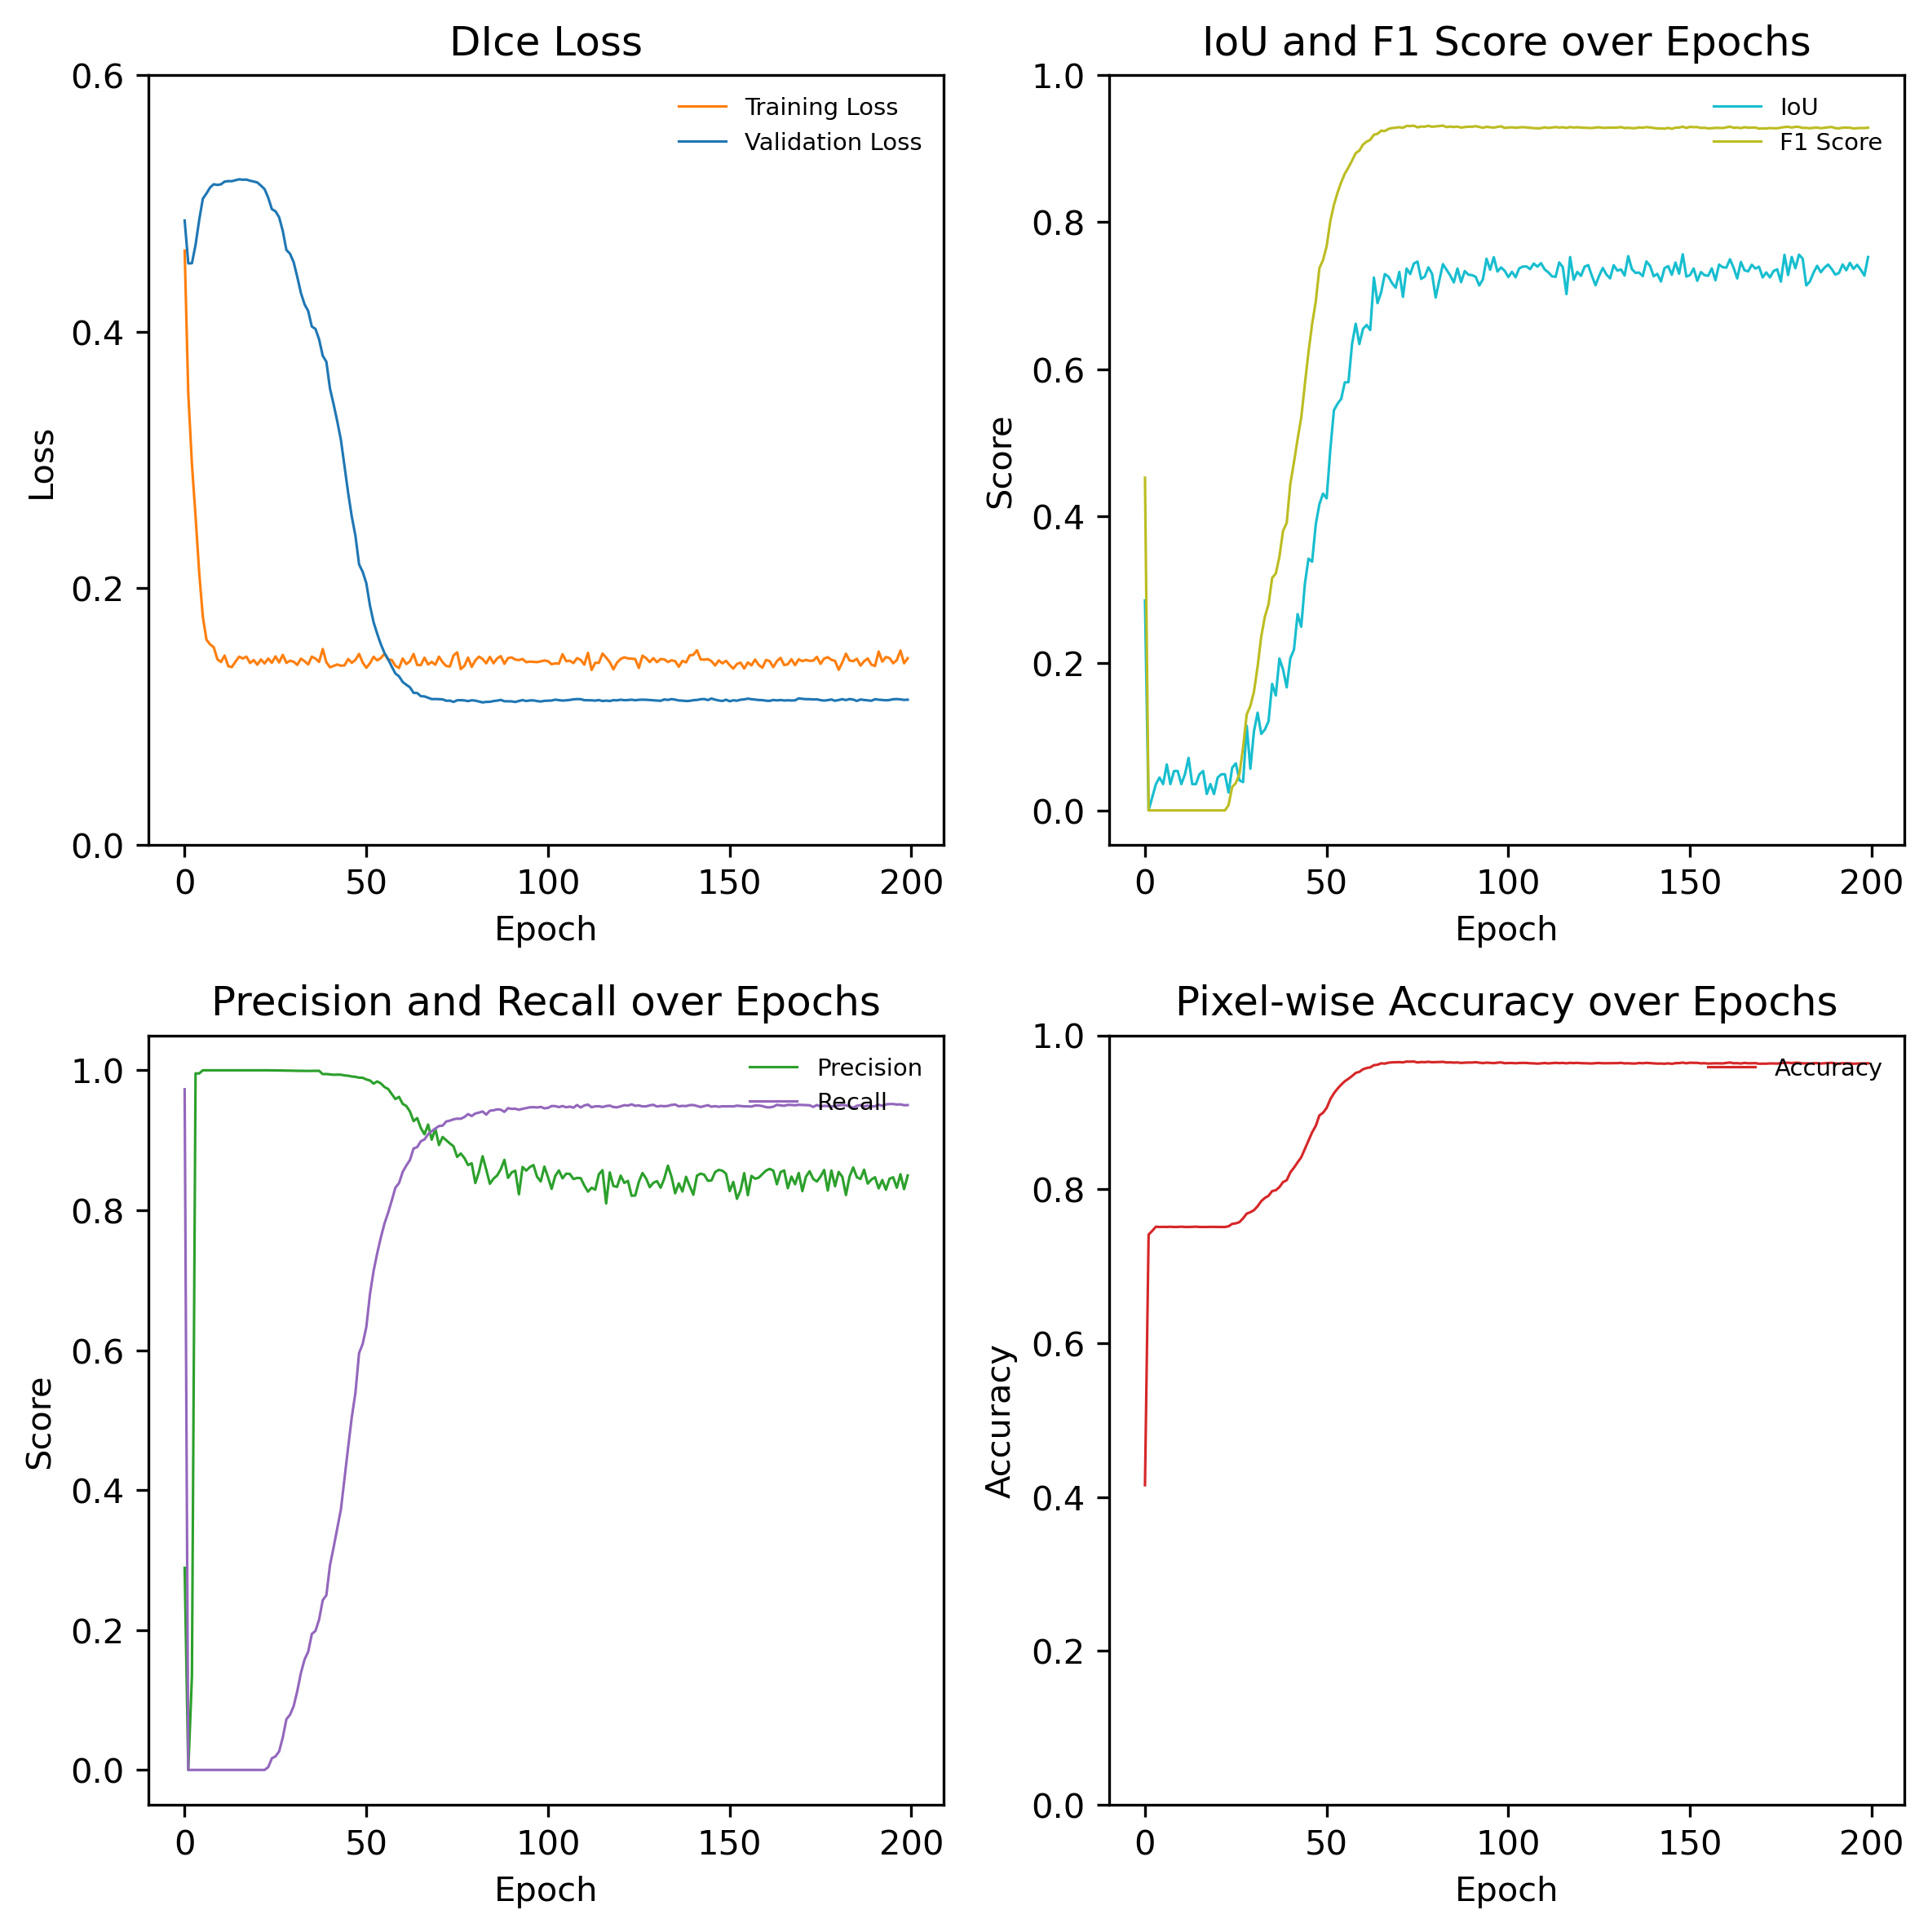

In [ ]:
max_tick = max(metrics_df["Training_loss"].max(), metrics_df["Validation_loss"].max())

plt.figure(figsize=(8,8), dpi=300)
plt.subplot(221)
sns.lineplot(data=metrics_df, x="Epoch", y="Training_loss", label="Training Loss", linewidth = 0.75, color="tab:orange")
sns.lineplot(data=metrics_df, x="Epoch", y="Validation_loss", label="Validation Loss", linewidth = 0.75, color="tab:blue")
# plt.xticks(range(0,max_tick+50,50))
plt.yticks(np.arange(0, max_tick+0.1, 0.2))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dice Loss")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.subplot(222)
# max_tick = max(metrics_df["IoU"].max(), metrics_df["F1"].max())
sns.lineplot(data=metrics_df, x="Epoch", y="IoU", label="IoU", color="tab:cyan",linewidth = 0.75)
sns.lineplot(data=metrics_df, x="Epoch", y="F1", label="F1 Score", color="tab:olive", linewidth = 0.75)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.yticks(np.arange(0, 1+0.2, 0.2))
plt.title("IoU and F1 Score over Epochs")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.subplot(223)
sns.lineplot(data=metrics_df, x="Epoch", y="Precision", label="Precision",color="tab:green",linewidth = 0.75)
sns.lineplot(data=metrics_df, x="Epoch", y="Recall", label="Recall",color="tab:purple",linewidth = 0.75)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.yticks(np.arange(0, 1+0.2, 0.2))
plt.title("Precision and Recall over Epochs")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.subplot(224)
sns.lineplot(data=metrics_df, x="Epoch", y="Accuracy",label="Accuracy", color="tab:red",linewidth=0.75)
plt.title("Pixel-wise Accuracy over Epochs")
plt.yticks(np.arange(0, 1+0.2, 0.2))
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.tight_layout()
plt.savefig("output/3-Model_performance/model_performance.pdf", format = "pdf")
plt.show()

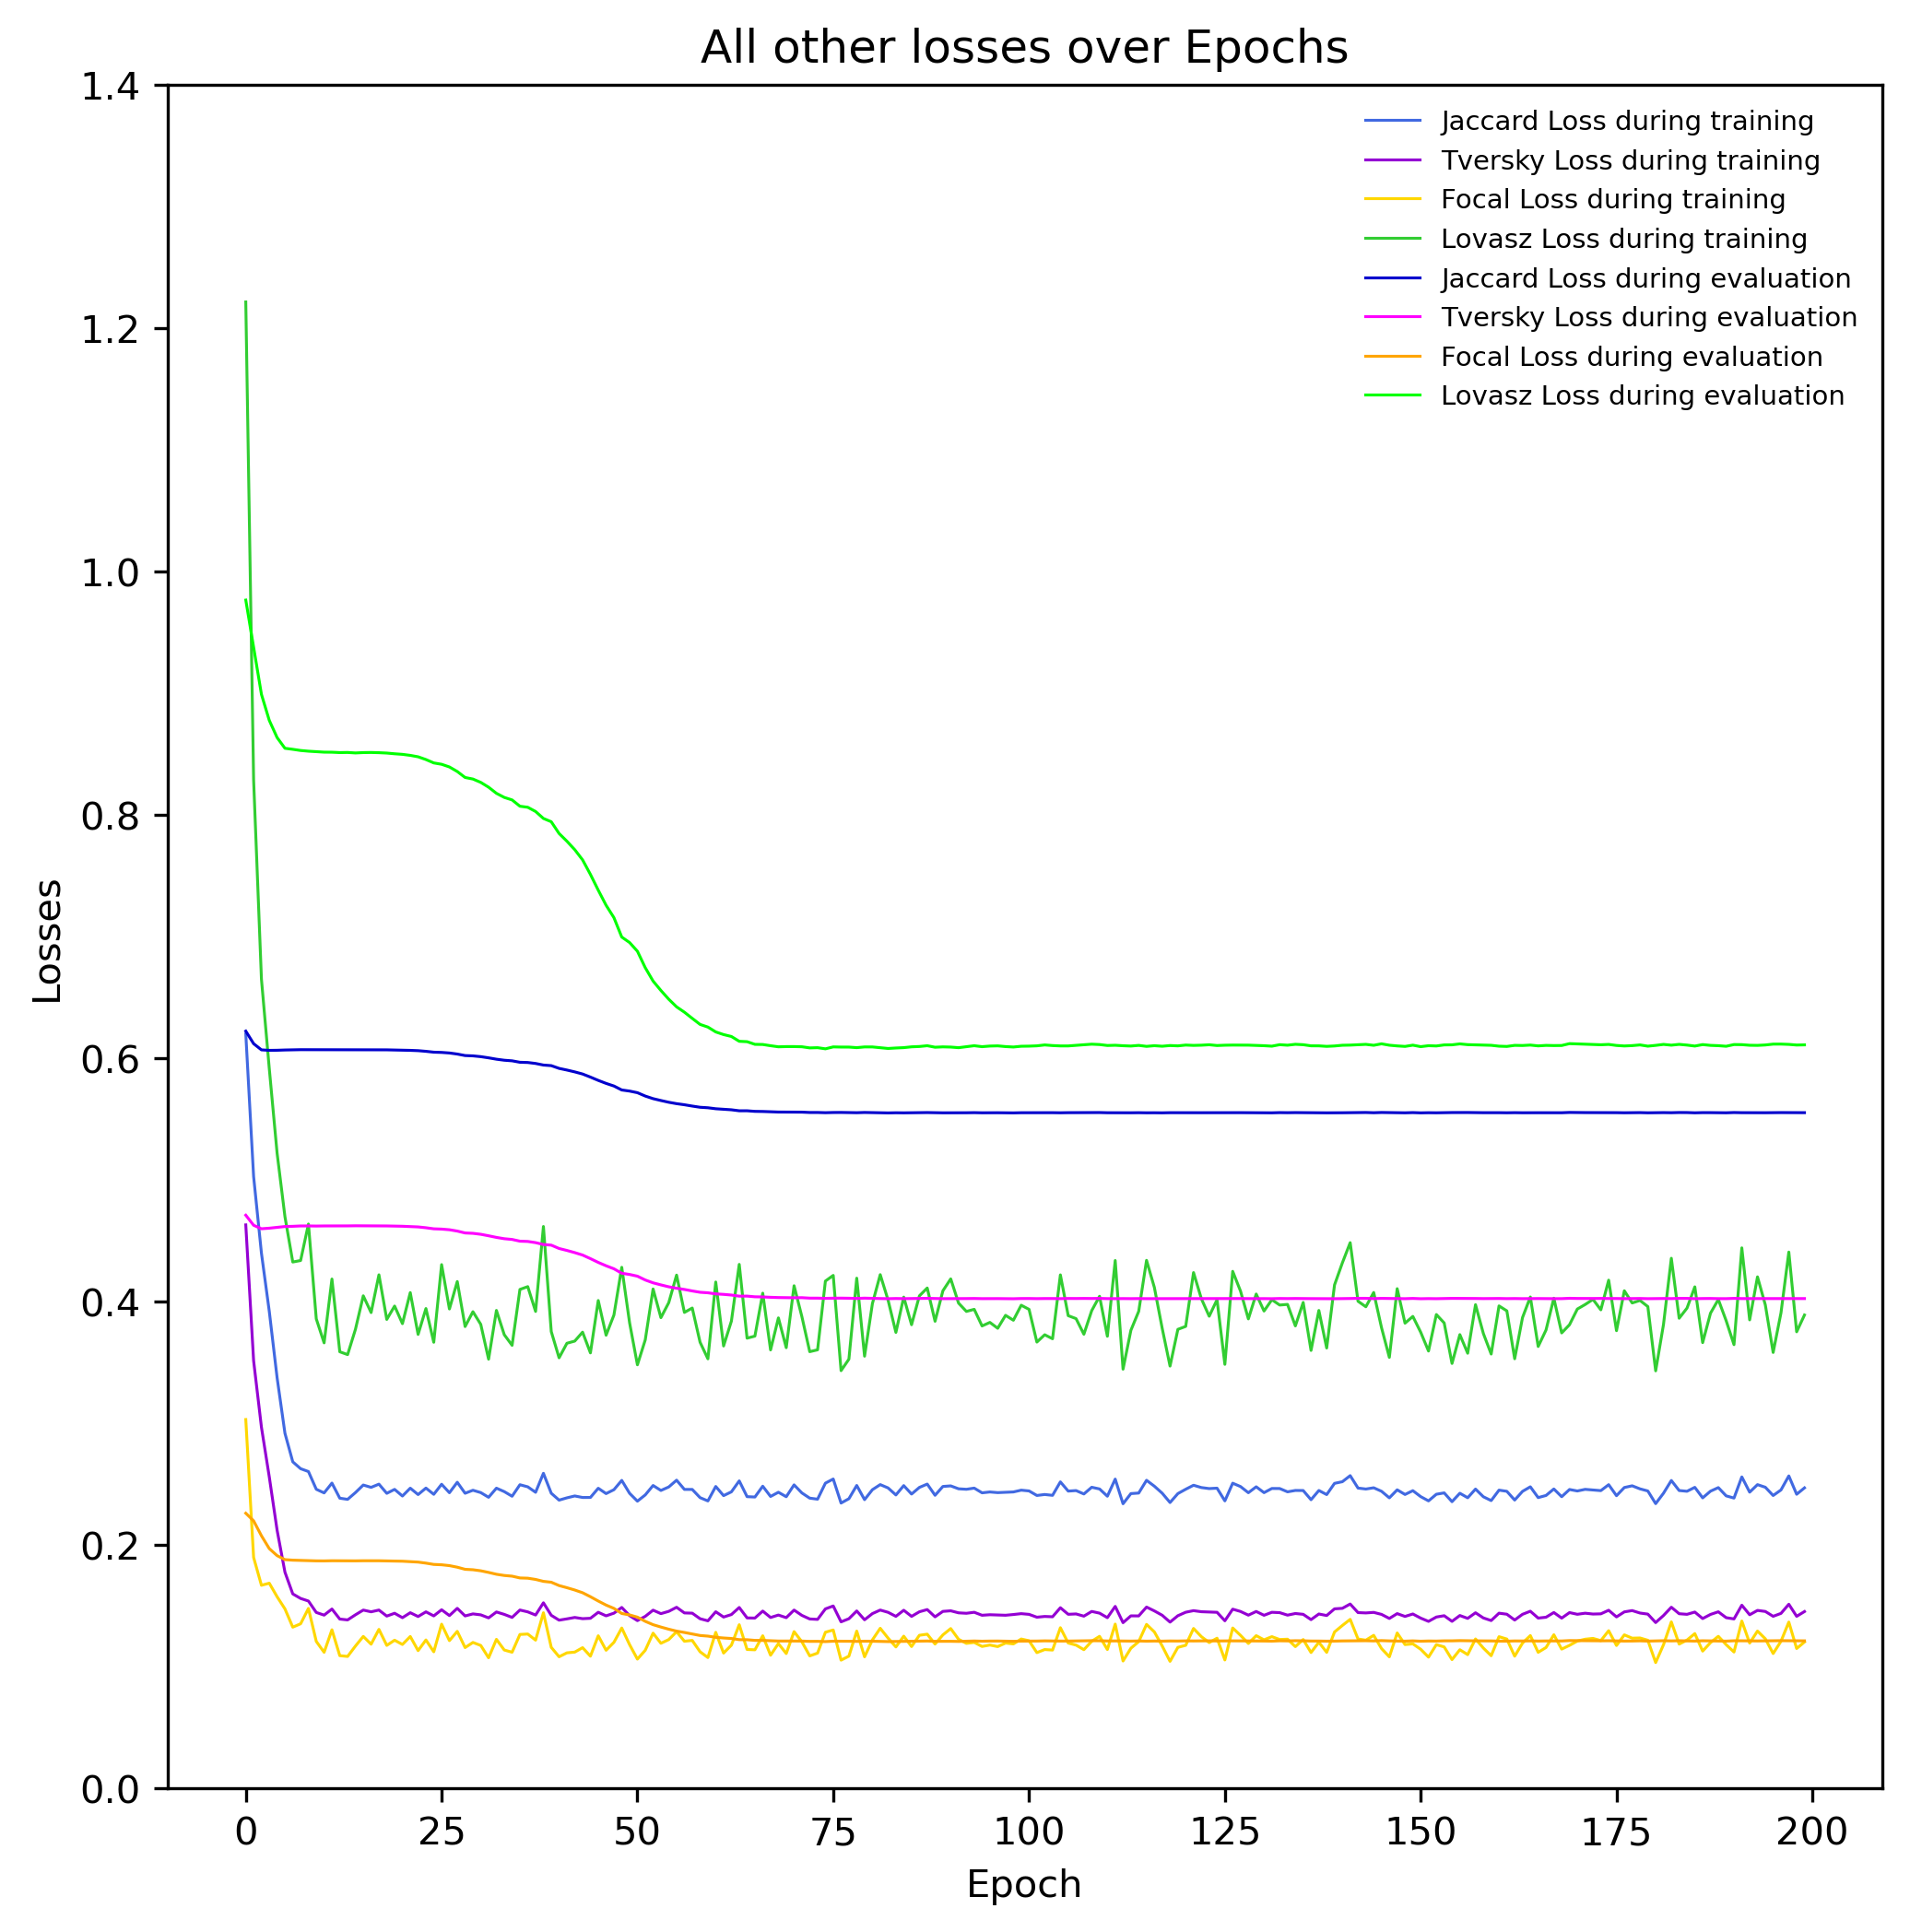

In [28]:
max_tick = max(metrics_df["Train_Jaccard_Loss"].max(), 
               metrics_df["Train_Tversky_Loss"].max(),
               metrics_df["Train_Focal_Loss"].max(),
               metrics_df["Train_Lovasz_Loss"].max(),
               metrics_df["Eval_Jaccard_Loss"].max(),
               metrics_df["Eval_Tversky_Loss"].max(),
               metrics_df["Eval_Focal_Loss"].max(),
               metrics_df["Eval_Lovasz_Loss"].max())

plt.figure(figsize=(8,8), dpi=300)
# plt.subplot(221)
sns.lineplot(data=metrics_df, x="Epoch", y="Train_Jaccard_Loss", label="Jaccard Loss during training", linewidth = 0.75, color="royalblue")
sns.lineplot(data=metrics_df, x="Epoch", y="Train_Tversky_Loss", label="Tversky Loss during training", linewidth = 0.75, color="darkviolet")
sns.lineplot(data=metrics_df, x="Epoch", y="Train_Focal_Loss", label="Focal Loss during training", linewidth = 0.75, color="gold")
sns.lineplot(data=metrics_df, x="Epoch", y="Train_Lovasz_Loss", label="Lovasz Loss during training", linewidth = 0.75, color="limegreen")

sns.lineplot(data=metrics_df, x="Epoch", y="Eval_Jaccard_Loss", label="Jaccard Loss during evaluation", linewidth = 0.75, color="mediumblue")
sns.lineplot(data=metrics_df, x="Epoch", y="Eval_Tversky_Loss", label="Tversky Loss during evaluation", linewidth = 0.75, color="magenta")
sns.lineplot(data=metrics_df, x="Epoch", y="Eval_Focal_Loss", label="Focal Loss during evaluation", linewidth = 0.75, color="orange")
sns.lineplot(data=metrics_df, x="Epoch", y="Eval_Lovasz_Loss", label="Lovasz Loss during evaluation", linewidth = 0.75, color="lime")

plt.title("All other losses over Epochs")
plt.yticks(np.arange(0, max_tick+0.2, 0.2))
plt.xlabel("Epoch")
plt.ylabel("Losses")
plt.legend(fontsize=7, loc="upper right", frameon=False)

plt.savefig("output/3-Model_performance/other_losses.pdf", format = "pdf")

## Model selection

In [15]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False) # set to 1 for easy plotting
len_test_loader = len(test_loader)

In [ ]:
test_iou_scores = []
test_f1_scores = []
test_precision_scores = []
test_recall_scores = []
test_accuracy_scores = []
test_fbeta_scores = []
test_losses = []

test_JaccardLosses= []
test_TverskyLosses= []
test_FocalLosses = []
test_LovaszLosses = []

all_models = sorted(glob.glob(os.path.join("my_model", "*"), recursive=True))
# check the models
for trained_model in all_models:
    # model_select = 148
    print(f"Testing model {trained_model.split('/')[-1]}...", end = "")
    model = smp.from_pretrained(f'{trained_model}',local_files_only=True).to(device)

    model.eval() # enable model evaluation mode

    test_loss = 0
    test_JaccardLoss= 0
    test_TverskyLoss= 0
    test_FocalLoss = 0
    test_LovaszLoss = 0

    # stop gradient calculation
    with torch.no_grad():
        all_tp, all_fp, all_fn, all_tn = [], [], [], []
        for image, masks, types in test_loader:
            # print(types)
            
            # print(masks.shape)

            img_np = image.squeeze(0).permute(1, 2, 0).numpy() # make sure (H, W, C)
            mask_np = masks.squeeze(0).numpy()
            # print(mask_np.shape)
            image = image.to(device)
            masks = masks.to(device)

            outputs = model(image)
            loss = loss_fn(outputs, masks)
            outputs = torch.sigmoid(outputs)

            JaccardLoss = JaccardLoss_loss_fn(outputs, masks)
            TverskyLoss = TverskyLoss_loss_fn(outputs, masks)
            FocalLoss = FocalLoss_loss_fn(outputs, masks)
            LovaszLoss = LovaszLoss_loss_fn(outputs, masks)
            
            pred_mask = (outputs.cpu() > 0.5).squeeze(0).numpy()
            # fig, axes = plt.subplots(1, 5, figsize=(15, 3))

            # axes[0].imshow(img_np)
            # axes[0].set_title("Image")
            # axes[0].axis("off")

            # axes[1].imshow(mask_np[0], cmap="gray")
            # axes[1].set_title("Mask")
            # axes[1].axis("off")

            # axes[2].imshow(mask_np[1], cmap="gray")
            # axes[2].set_title("Background")
            # # axes[2].axis("off")
            # axes[2].set_xticks([])
            # axes[2].set_yticks([])
            # axes[2].spines["left"].set_linewidth(0.75)
            # axes[2].spines["right"].set_linewidth(0.75)
            # axes[2].spines["top"].set_linewidth(0.75)
            # axes[2].spines["bottom"].set_linewidth(0.75)

            # # axes[2].imshow(img_np)
            # axes[3].imshow(pred_mask[0], cmap="gray") # ListedColormap(["#FFFFFF"])
            # axes[3].set_title("Pred Mask")
            # axes[3].axis("off")

            # axes[4].imshow(pred_mask[1], cmap="gray") # ListedColormap(["#FFFFFF"])
            # axes[4].set_title("Pred Background")
            # # axes[4].axis("off")
            # axes[4].set_xticks([])
            # axes[4].set_yticks([])
            # axes[4].spines["left"].set_linewidth(0.75)
            # axes[4].spines["right"].set_linewidth(0.75)
            # axes[4].spines["top"].set_linewidth(0.75)
            # axes[4].spines["bottom"].set_linewidth(0.75)

            # plt.tight_layout()
            # plt.savefig(f"output/4-pred_ROIs/{Path(types['image'][0]).stem}.pdf", format = "pdf")
            # plt.close()
            test_loss += loss.item()
            test_JaccardLoss += JaccardLoss.item()
            test_TverskyLoss += TverskyLoss.item()
            test_FocalLoss += FocalLoss.item()
            test_LovaszLoss  += LovaszLoss.item()
            
            # print(f"{outputs[:, 0:1].shape}")
            tp, fp, fn, tn = smp.metrics.get_stats(
                outputs[:,0], masks.long()[:,0], mode='binary', threshold=0.5#, num_classes=2
            )

            all_tp.append(tp)
            all_fp.append(fp)
            all_fn.append(fn)
            all_tn.append(tn)

        avg_test_loss = test_loss / len_test_loader
        avg_test_JaccardLosses = test_JaccardLoss / len_test_loader
        avg_test_TverskyLosses = test_TverskyLoss / len_test_loader
        avg_test_FocalLosses  = test_FocalLoss / len_test_loader
        avg_test_LovaszLosses  = test_LovaszLoss / len_test_loader

        test_losses.append(avg_test_loss)
        test_JaccardLosses.append(avg_test_JaccardLosses)
        test_TverskyLosses.append(avg_test_TverskyLosses)
        test_FocalLosses.append(avg_test_FocalLosses)  
        test_LovaszLosses.append(avg_test_LovaszLosses) 
        
        # scheduler.step(avg_val_loss)
        
        # Concatenate statistics
        tp = torch.cat(all_tp, dim=0)
        fp = torch.cat(all_fp, dim=0)
        fn = torch.cat(all_fn, dim=0)
        tn = torch.cat(all_tn, dim=0)

        # Compute metrics
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
        f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
        precision = smp.metrics.precision(tp, fp, fn, tn, reduction="macro")
        recall = smp.metrics.recall(tp, fp, fn, tn, reduction="micro-imagewise")
        accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")
        fbeta = smp.metrics.fbeta_score(tp, fp, fn, tn, reduction="macro")

        # current_lr = optimizer.param_groups[0]['lr']

        # pbar.set_postfix({"Validation IOU": iou.item(), "Dice": avg_val_loss, "current learning rate": current_lr})

        test_iou_scores.append(float(iou.cpu().numpy()))
        test_f1_scores.append(float(f1.cpu().numpy()))
        test_precision_scores.append(float(precision.cpu().numpy()))
        test_recall_scores.append(float(recall.cpu().numpy()))
        test_accuracy_scores.append(float(accuracy.cpu().numpy()))
        test_fbeta_scores.append(float(fbeta.cpu().numpy()))
test_metrics_df = pd.DataFrame({
    "Model": [int(x.split('/')[-1]) for x in all_models],
    "Model_str": [x.split('/')[-1] for x in all_models],
    "IoU": test_iou_scores,
    "F1": test_f1_scores,
    "Fbeta": test_fbeta_scores,
    "Precision": test_precision_scores,
    "Recall": test_recall_scores,
    "Accuracy" : test_accuracy_scores,
    "Test_loss" : test_losses,
    "Test_Jaccard_Loss": test_JaccardLosses,
    "Test_Tversky_Loss": test_TverskyLosses,
    "Test_Focal_Loss" : test_FocalLosses ,
    "Test_Lovasz_Loss": test_LovaszLosses 
})

# os.makedirs("Model_performance", exist_ok=True)
test_metrics_df.sort_values(by="Model").to_csv("output/3-Model_performance/test_metrics_df.csv", index=False)

Testing model 101...Loading weights from local directory
Testing model 103...Loading weights from local directory
Testing model 104...Loading weights from local directory
Testing model 105...Loading weights from local directory
Testing model 107...Loading weights from local directory
Testing model 109...Loading weights from local directory
Testing model 110...Loading weights from local directory
Testing model 114...Loading weights from local directory
Testing model 117...Loading weights from local directory
Testing model 133...Loading weights from local directory
Testing model 148...Loading weights from local directory
Testing model 52...Loading weights from local directory
Testing model 53...Loading weights from local directory
Testing model 54...Loading weights from local directory
Testing model 55...Loading weights from local directory
Testing model 56...Loading weights from local directory
Testing model 57...Loading weights from local directory
Testing model 58...Loading weights fr

In [92]:
idx = test_metrics_df["IoU"].idxmax()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the highest IoU. IoU:{test_metrics_df.loc[idx]['IoU']: .2f} Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")
idx = test_metrics_df["Recall"].idxmax()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the highest Recall. IoU:{test_metrics_df.loc[idx]['IoU']: .2f} Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")
idx = test_metrics_df["Precision"].idxmin()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the highest Precision. IoU:{test_metrics_df.loc[idx]['IoU']: .2f} Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")
idx = test_metrics_df["Test_loss"].idxmin()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the lowest loss. IoU:{test_metrics_df.loc[idx]['IoU']: .2f} Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")
idx = test_metrics_df["F1"].idxmax()
print(f"Model {test_metrics_df.loc[idx]['Model']} has the highest F1. IoU:{test_metrics_df.loc[idx]['IoU']: .2f} Recall:{test_metrics_df.loc[idx]['Recall']: .2f} Precision:{test_metrics_df.loc[idx]['Precision']: .2f} F1:{test_metrics_df.loc[idx]['F1']: .2f} Loss:{test_metrics_df.loc[idx]['Test_loss']: .3f}")

Model 114 has the highest IoU. IoU: 0.73 Recall: 0.93 Precision: 0.84 F1: 0.90 Loss: 0.143
Model 133 has the highest Recall. IoU: 0.73 Recall: 0.93 Precision: 0.83 F1: 0.90 Loss: 0.143
Model 133 has the highest Precision. IoU: 0.73 Recall: 0.93 Precision: 0.83 F1: 0.90 Loss: 0.143
Model 65 has the lowest loss. IoU: 0.72 Recall: 0.91 Precision: 0.87 F1: 0.90 Loss: 0.140
Model 67 has the highest F1. IoU: 0.72 Recall: 0.91 Precision: 0.86 F1: 0.90 Loss: 0.140


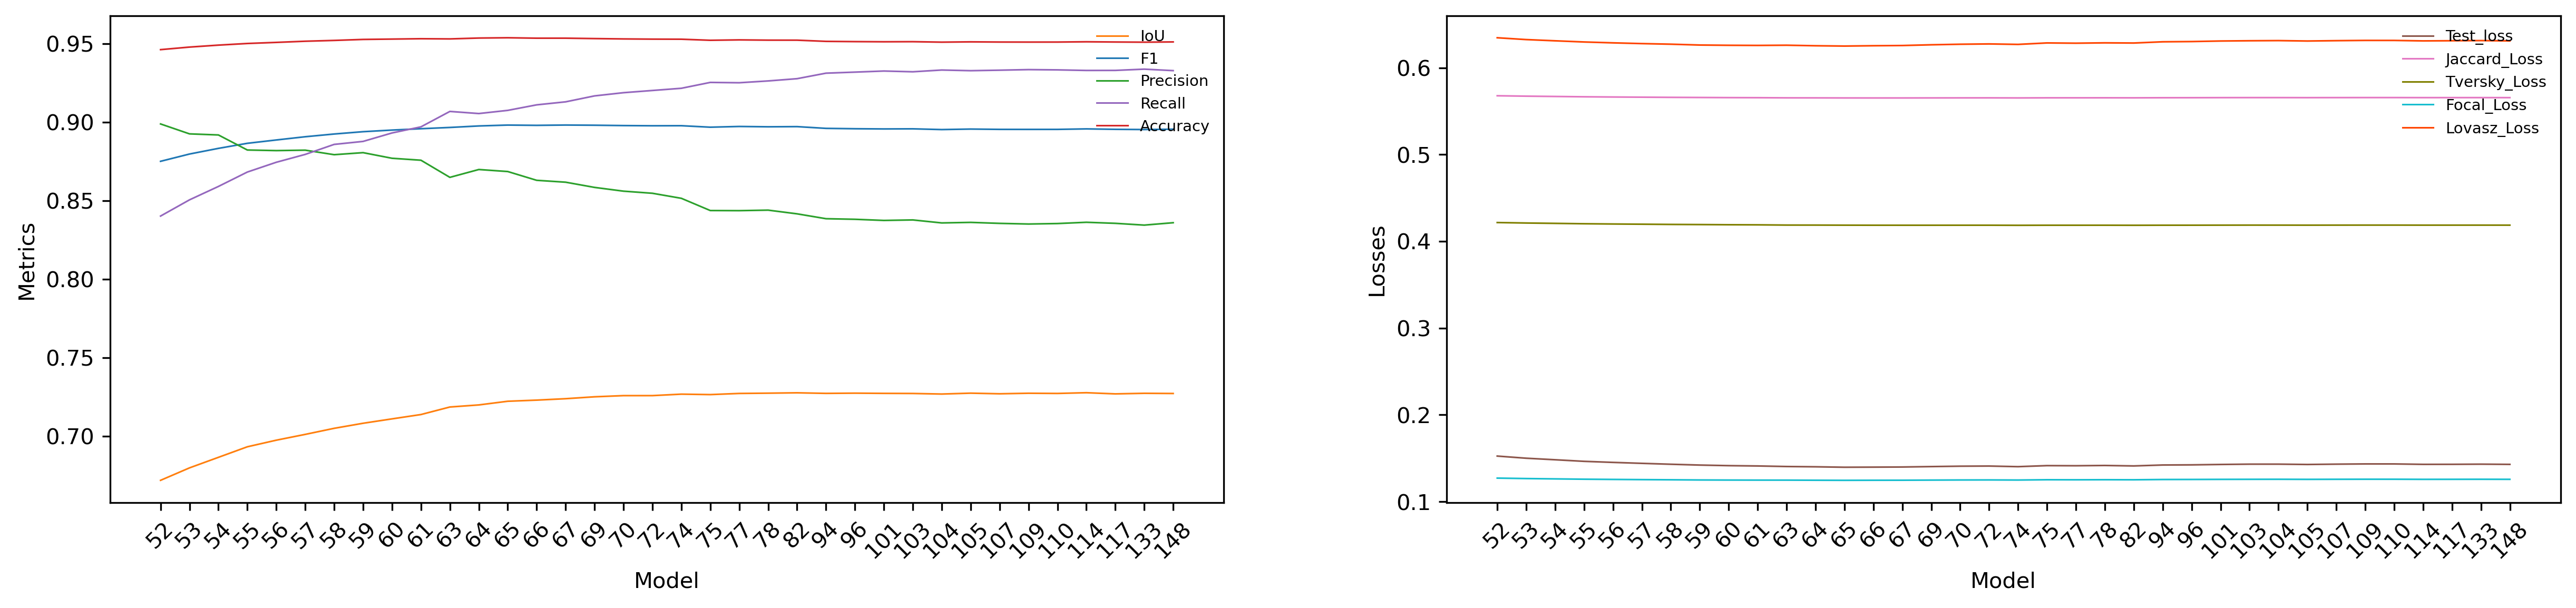

In [95]:
plt.figure(figsize=(20,4), dpi=300)
plt.subplot(121)
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "IoU", linewidth = 0.75, label="IoU", color="tab:orange" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "F1", linewidth = 0.75, label="F1",color="tab:blue" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Precision", linewidth = 0.75, label="Precision",color="tab:green" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Recall", linewidth = 0.75, label="Recall",color="tab:purple" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Accuracy", linewidth = 0.75, label="Accuracy",color="tab:red" )
plt.xticks(rotation = 45)
plt.xlabel("Model")
plt.ylabel("Metrics")
# plt.yscale('log')
plt.legend(fontsize=7,loc="upper right", frameon=False)

plt.subplot(122)
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_loss", linewidth = 0.75, label="Test_loss",color="tab:brown" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_Jaccard_Loss", linewidth = 0.75, label="Jaccard_Loss",color="tab:pink" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_Tversky_Loss", linewidth = 0.75, label="Tversky_Loss",color="olive" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_Focal_Loss", linewidth = 0.75, label="Focal_Loss",color="tab:cyan" )
sns.lineplot(data=test_metrics_df.sort_values(by = "Model"), x = "Model_str", y = "Test_Lovasz_Loss", linewidth = 0.75, label="Lovasz_Loss",color="orangered" )
plt.xticks(rotation = 45)
plt.xlabel("Model")
plt.ylabel("Losses")
# plt.yscale('log')
plt.legend(fontsize=7,loc="upper right", frameon=False)

plt.savefig("output/3-Model_performance/test_metrics_vs_models.pdf", format = "pdf",dpi = 300,bbox_inches="tight")


In [ ]:
test_iou_scores = []
test_f1_scores = []
test_precision_scores = []
test_recall_scores = []
test_accuracy_scores = []
test_fbeta_scores = []
test_losses = []

test_JaccardLosses= []
test_TverskyLosses= []
test_FocalLosses = []
test_LovaszLosses = []

model_select = 148 # change this to select different models

model = smp.from_pretrained(f'my_model/{model_select}',local_files_only=True).to(device)

model.eval() # enable model evaluation mode

test_loss = 0
test_JaccardLoss= 0
test_TverskyLoss= 0
test_FocalLoss = 0
test_LovaszLoss = 0

    # stop gradient calculation
with torch.no_grad():
    all_tp, all_fp, all_fn, all_tn = [], [], [], []
    for image, masks, types in test_loader:
        # print(types)
            
        # print(masks.shape)

        img_np = image.squeeze(0).permute(1, 2, 0).numpy() # make sure (H, W, C)
        mask_np = masks.squeeze(0).numpy()
        # print(mask_np.shape)
        image = image.to(device)
        masks = masks.to(device)

        outputs = model(image)
        loss = loss_fn(outputs, masks)
        outputs = torch.sigmoid(outputs)

        JaccardLoss = JaccardLoss_loss_fn(outputs, masks)
        TverskyLoss = TverskyLoss_loss_fn(outputs, masks)
        FocalLoss = FocalLoss_loss_fn(outputs, masks)
        LovaszLoss = LovaszLoss_loss_fn(outputs, masks)
            
        pred_mask = (outputs.cpu() > 0.5).squeeze(0).numpy()
        fig, axes = plt.subplots(1, 5, figsize=(15, 3))

        axes[0].imshow(img_np)
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(mask_np[0], cmap="gray")
        axes[1].set_title("Mask")
        axes[1].axis("off")

        axes[2].imshow(mask_np[1], cmap="gray")
        axes[2].set_title("Background")
        # axes[2].axis("off")
        axes[2].set_xticks([])
        axes[2].set_yticks([])
        axes[2].spines["left"].set_linewidth(0.75)
        axes[2].spines["right"].set_linewidth(0.75)
        axes[2].spines["top"].set_linewidth(0.75)
        axes[2].spines["bottom"].set_linewidth(0.75)

        # axes[2].imshow(img_np)
        axes[3].imshow(pred_mask[0], cmap="gray") # ListedColormap(["#FFFFFF"])
        axes[3].set_title("Pred Mask")
        axes[3].axis("off")

        axes[4].imshow(pred_mask[1], cmap="gray") # ListedColormap(["#FFFFFF"])
        axes[4].set_title("Pred Background")
        # axes[4].axis("off")
        axes[4].set_xticks([])
        axes[4].set_yticks([])
        axes[4].spines["left"].set_linewidth(0.75)
        axes[4].spines["right"].set_linewidth(0.75)
        axes[4].spines["top"].set_linewidth(0.75)
        axes[4].spines["bottom"].set_linewidth(0.75)

        plt.tight_layout()
        plt.savefig(f"output/4-pred_ROIs/{Path(types['image'][0]).stem}.pdf", format = "pdf")
        plt.close()
        test_loss += loss.item()
        test_JaccardLoss += JaccardLoss.item()
        test_TverskyLoss += TverskyLoss.item()
        test_FocalLoss += FocalLoss.item()
        test_LovaszLoss  += LovaszLoss.item()
            
        # print(f"{outputs[:, 0:1].shape}")
        tp, fp, fn, tn = smp.metrics.get_stats(
            outputs[:,0], masks.long()[:,0], mode='binary', threshold=0.5#, num_classes=2
        )

        all_tp.append(tp)
        all_fp.append(fp)
        all_fn.append(fn)
        all_tn.append(tn)

    avg_test_loss = test_loss / len_test_loader
    avg_test_JaccardLosses = test_JaccardLoss / len_test_loader
    avg_test_TverskyLosses = test_TverskyLoss / len_test_loader
    avg_test_FocalLosses  = test_FocalLoss / len_test_loader
    avg_test_LovaszLosses  = test_LovaszLoss / len_test_loader

    test_losses.append(avg_test_loss)
    test_JaccardLosses.append(avg_test_JaccardLosses)
    test_TverskyLosses.append(avg_test_TverskyLosses)
    test_FocalLosses.append(avg_test_FocalLosses)  
    test_LovaszLosses.append(avg_test_LovaszLosses) 
        
    # scheduler.step(avg_val_loss)
        
    # Concatenate statistics
    tp = torch.cat(all_tp, dim=0)
    fp = torch.cat(all_fp, dim=0)
    fn = torch.cat(all_fn, dim=0)
    tn = torch.cat(all_tn, dim=0)

    # Compute metrics
    iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
    f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
    precision = smp.metrics.precision(tp, fp, fn, tn, reduction="macro")
    recall = smp.metrics.recall(tp, fp, fn, tn, reduction="micro-imagewise")
    accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")
    fbeta = smp.metrics.fbeta_score(tp, fp, fn, tn, reduction="macro")

    # current_lr = optimizer.param_groups[0]['lr']

    # pbar.set_postfix({"Validation IOU": iou.item(), "Dice": avg_val_loss, "current learning rate": current_lr})

    test_iou_scores.append(float(iou.cpu().numpy()))
    test_f1_scores.append(float(f1.cpu().numpy()))
    test_precision_scores.append(float(precision.cpu().numpy()))
    test_recall_scores.append(float(recall.cpu().numpy()))
    test_accuracy_scores.append(float(accuracy.cpu().numpy()))
    test_fbeta_scores.append(float(fbeta.cpu().numpy()))

test_metrics_selected_model = pd.DataFrame({
    "Model": model_select,
    # "Model_str": [x.split('/')[-1] for x in all_models],
    "IoU": test_iou_scores,
    "F1": test_f1_scores,
    "Fbeta": test_fbeta_scores,
    "Precision": test_precision_scores,
    "Recall": test_recall_scores,
    "Accuracy" : test_accuracy_scores,
    "Test_loss" : test_losses,
    "Test_Jaccard_Loss": test_JaccardLosses,
    "Test_Tversky_Loss": test_TverskyLosses,
    "Test_Focal_Loss" : test_FocalLosses ,
    "Test_Lovasz_Loss": test_LovaszLosses 
})

# os.makedirs("Model_performance", exist_ok=True)
test_metrics_selected_model.to_csv(f"output/3-Model_performance/test_metrics_model{model_select}.csv", index=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Loading weights from local directory


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9921569].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data

# Fine-tuning (Optional)

In [ ]:
data_dir = r"Dataset"
train_images = sorted(glob.glob(os.path.join(data_dir, "CXR", "*.png"), recursive=True))
train_labels = sorted(glob.glob(os.path.join(data_dir, "Mask", "*.png"), recursive=True))
# convert to dict for easy manipulation
data_dicts = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
len(data_dicts)

In [ ]:
random.seed(42)
random.shuffle(data_dicts)
# calculate splits
train_portion = math.ceil(len(data_dicts) * 0.7)
test_portion = math.floor(len(data_dicts) * 0.15)
valid_portion = len(data_dicts) - test_portion - train_portion
print(train_portion)
print(test_portion)
print(valid_portion)
print((train_portion + test_portion + valid_portion) == len(data_dicts))
train_files, test_files, val_files = data_dicts[0:train_portion], data_dicts[train_portion:(train_portion+test_portion)], data_dicts[(train_portion+test_portion):(train_portion + test_portion + valid_portion)]

In [ ]:
with open("output/train_files.pkl", "wb") as f:
    pickle.dump(train_files,f)

with open("output/val_files.pkl", "wb") as f:
    pickle.dump(val_files,f)

with open("output/test_files.pkl", "wb") as f:
    pickle.dump(test_files,f)

In [8]:
train_dataset = SegDataset(train_files, transform=train_transform)
val_dataset   = SegDataset(val_files, transform=val_transform)
test_dataset   = SegDataset(test_files, transform=val_transform)

NameError: name 'train_transform' is not defined

In [ ]:
# pre-defined best metrics, for model selection and saving
best_f1         = 0.6
best_recall     = 0.7
best_acc        = 0.7
best_train_loss = 0.3
best_val_loss   = 0.3
best_IOU        = 0.5

# simple hyperparameters, normally this set up can have a result of around 0.7 IoU, depends on the number of masks
epochs          = 200 # train for 200 epochs
batch_size      = 16 # adjust batch to optimize the use of GPU, 224 * 224 @ batch size 16 takes up around 3GB of GPU Memory

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# lists to store metrics
train_losses = []
eval_losses = []
iou_scores = []
f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []
fbeta_scores = []
num_epoch = []

JaccardLosses = []
TverskyLosses = []
FocalLosses = []
LovaszLosses = []

eval_JaccardLosses = []
eval_TverskyLosses= []
eval_FocalLosses  = []
eval_LovaszLosses = []

In [ ]:
pbar = tqdm(range(epochs))
len_loader = len(train_loader)
len_eval_loader = len(val_loader)

for epoch in pbar:
    epoch_loss = 0
    epoch_JaccardLoss = 0
    epoch_TverskyLoss = 0
    epoch_FocalLoss = 0
    epoch_LovaszLoss = 0

    num_epoch.append(epoch)
    
    model.train() # enable training mode
    for image, masks, types in train_loader:
        pbar.set_description("Training ...")
        
        # print(f"{image.shape} {masks.shape}")
        # img_np = image.squeeze(0).permute(1, 2, 0).numpy() # make sure (H, W, C)
        # print(f"{img_np.shape}")
        # mask_np = masks.squeeze(0).permute(1, 2, 0).numpy()
        # fig, axes = plt.subplots(1, 3, figsize=(8, 4))

        # axes[0].imshow(img_np)
        # axes[0].set_title("Image")
        # axes[0].axis("off")

        # axes[1].imshow(mask_np, cmap="gray")
        # axes[1].set_title("Mask")
        # axes[1].axis("off")

        # axes[2].imshow(img_np)
        # axes[2].imshow(mask_np, cmap="Reds", alpha=0.4) # ListedColormap(["#FFFFFF"])
        # axes[2].set_title("Overlay")
        # axes[2].axis("off")

        # plt.tight_layout()
        # plt.show()

        image = image.to(device)
        masks = masks.to(device)
        # print(f"{image.shape} {masks.shape}")
        optimizer.zero_grad()

        outputs = model(image)
        loss = loss_fn(outputs, masks) # compute dice loss

        loss.backward() # back propagation
        optimizer.step() # optimize weights

        epoch_loss += loss.item()

        # compute other loss
        JaccardLoss = JaccardLoss_loss_fn(outputs, masks)
        TverskyLoss = TverskyLoss_loss_fn(outputs, masks)
        FocalLoss = FocalLoss_loss_fn(outputs, masks)
        LovaszLoss = LovaszLoss_loss_fn(outputs, masks)

        epoch_JaccardLoss += JaccardLoss.item()
        epoch_TverskyLoss += TverskyLoss.item()
        epoch_FocalLoss += FocalLoss.item()
        epoch_LovaszLoss += LovaszLoss.item()
        # print(f"{image.shape} {masks.shape}")
    #     break
    # break
    
    avg_train_loss = epoch_loss / len_loader
    avg_JaccardLoss = epoch_JaccardLoss / len_loader
    avg_TverskyLoss = epoch_TverskyLoss / len_loader
    avg_FocalLoss = epoch_FocalLoss / len_loader
    avg_LovaszLoss = epoch_LovaszLoss / len_loader

    train_losses.append(avg_train_loss)
    JaccardLosses.append(avg_JaccardLoss)
    TverskyLosses.append(avg_TverskyLoss)
    FocalLosses.append(avg_FocalLoss)
    LovaszLosses.append(avg_LovaszLoss)

    # evaluation loop
    model.eval() # enable model evaluation mode
    # stop gradient calculation
    val_loss = 0
    val_JaccardLoss= 0
    val_TverskyLoss= 0
    val_FocalLoss = 0
    val_LovaszLoss = 0

    with torch.no_grad():
        all_tp, all_fp, all_fn, all_tn = [], [], [], []
        for image, masks,types in val_loader:
            pbar.set_description("Validating ...")
            # print(masks)
            image = image.to(device)
            masks = masks.to(device)

            outputs = model(image)
            loss = loss_fn(outputs, masks)

            val_loss += loss.item()
            outputs = torch.sigmoid(outputs)
            # print(f"{outputs[:, 0:1].shape}")
            tp, fp, fn, tn = smp.metrics.get_stats(
                outputs[:,0], masks.long()[:,0], mode='binary', threshold=0.5#, num_classes=2
            )

            JaccardLoss = JaccardLoss_loss_fn(outputs, masks)
            TverskyLoss = TverskyLoss_loss_fn(outputs, masks)
            FocalLoss = FocalLoss_loss_fn(outputs, masks)
            LovaszLoss = LovaszLoss_loss_fn(outputs, masks)

            val_JaccardLoss += JaccardLoss.item()
            val_TverskyLoss += TverskyLoss.item()
            val_FocalLoss += FocalLoss.item()
            val_LovaszLoss += LovaszLoss.item()
            
            all_tp.append(tp)
            all_fp.append(fp)
            all_fn.append(fn)
            all_tn.append(tn)

        avg_val_loss = val_loss / len_eval_loader
        avg_eval_JaccardLoss = val_JaccardLoss / len_eval_loader
        avg_eval_TverskyLoss = val_TverskyLoss / len_eval_loader
        avg_eval_FocalLoss  = val_FocalLoss / len_eval_loader
        avg_eval_LovaszLoss = val_LovaszLoss / len_eval_loader
        
        eval_losses.append(avg_val_loss)
        eval_JaccardLosses.append(avg_eval_JaccardLoss)
        eval_TverskyLosses.append(avg_eval_TverskyLoss)
        eval_FocalLosses.append(avg_eval_FocalLoss)
        eval_LovaszLosses.append(avg_eval_LovaszLoss) 


        scheduler.step(avg_val_loss)
        
        # Concatenate statistics
        tp = torch.cat(all_tp, dim=0)
        fp = torch.cat(all_fp, dim=0)
        fn = torch.cat(all_fn, dim=0)
        tn = torch.cat(all_tn, dim=0)

        # Compute metrics
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
        f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
        precision = smp.metrics.precision(tp, fp, fn, tn, reduction="macro")
        recall = smp.metrics.recall(tp, fp, fn, tn, reduction="micro-imagewise")
        accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")
        fbeta = smp.metrics.fbeta_score(tp, fp, fn, tn, reduction="macro")

        current_lr = optimizer.param_groups[0]['lr']

        pbar.set_postfix({"Validation IOU": iou.item(), "Dice": avg_val_loss, "current learning rate": current_lr})

        iou_scores.append(float(iou.cpu().numpy()))
        f1_scores.append(float(f1.cpu().numpy()))
        precision_scores.append(float(precision.cpu().numpy()))
        recall_scores.append(float(recall.cpu().numpy()))
        accuracy_scores.append(float(accuracy.cpu().numpy()))
        fbeta_scores.append(float(fbeta.cpu().numpy()))

        

        if iou.item() > best_IOU or (avg_train_loss < best_train_loss and 
                                     avg_val_loss < best_val_loss and 
                                     f1 > best_f1 and 
                                     recall > best_recall and 
                                     accuracy > best_acc):
                best_f1     = f1
                best_recall = recall
                best_acc    = accuracy
                best_train_loss = avg_train_loss
                best_val_loss = avg_val_loss
                best_IOU = iou
                model.save_pretrained(f'./my_model_finetune/{epoch}', metrics={"epoch":epoch, 
                                                                      "IOU": iou.item(), 
                                                                      "accuracy": accuracy.item(), 
                                                                      "F1": f1.item(), 
                                                                      "Precision":precision.item(), 
                                                                      "Recall":recall.item(),
                                                                      "Dice":avg_val_loss})

metrics_df = pd.DataFrame({
    "Epoch": num_epoch,
    "IoU": iou_scores,
    "F1": f1_scores,
    "Fbeta": fbeta_scores,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "Accuracy" : accuracy_scores,
    "Training_loss" : train_losses,
    "Validation_loss": eval_losses,
    "Train_Jaccard_Loss": JaccardLosses,
    "Train_Tversky_Loss": TverskyLosses,
    "Train_Focal_Loss": FocalLosses,
    "Train_Lovasz_Loss": LovaszLosses,
    "Eval_Jaccard_Loss":eval_JaccardLosses ,
    "Eval_Tversky_Loss":eval_TverskyLosses,
    "Eval_Focal_Loss" : eval_FocalLosses  ,
    "Eval_Lovasz_Loss": eval_LovaszLosses 
})

metrics_df.to_csv("output/3-Model_performance/model_metrics_finetuned.csv", index=False)